In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_clean = pd.read_csv('../data/processed/card_profiler_clean.csv')
df_pca = pd.read_csv('../data/processed/df_pca.csv')

In [2]:
results = []
for n_comp in range(2, 6):
    X = df_pca.iloc[:, :n_comp]
    for k in range(2, 8):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        results.append({
            "n_comp": n_comp,
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, labels),
            "min_cluster_pct": pd.Series(labels).value_counts(normalize=True).min() * 100,
        })

df_grid = pd.DataFrame(results)
df_grid.round(3)

,n_comp,k,inertia,silhouette,min_cluster_pct
0,2,2,23542.396,0.431,31.288
1,2,3,13244.220,0.449,27.132
2,2,4,10414.983,0.422,19.343
3,2,5,8242.981,0.410,15.644
4,2,6,6689.621,0.395,11.867
5,2,7,5634.987,0.398,11.007
6,3,2,30681.085,0.368,31.199
7,3,3,20205.728,0.383,26.718
8,3,4,16448.251,0.389,20.930
9,3,5,13781.047,0.391,15.789


In [3]:
df_grid[df_grid["min_cluster_pct"] >= 10].sort_values("silhouette", ascending=False).round(3)


,n_comp,k,inertia,silhouette,min_cluster_pct
1,2,3,13244.220,0.449,27.132
0,2,2,23542.396,0.431,31.288
2,2,4,10414.983,0.422,19.343
3,2,5,8242.981,0.410,15.644
5,2,7,5634.987,0.398,11.007
4,2,6,6689.621,0.395,11.867
9,3,5,13781.047,0.391,15.789
8,3,4,16448.251,0.389,20.930
7,3,3,20205.728,0.383,26.718
6,3,2,30681.085,0.368,31.199


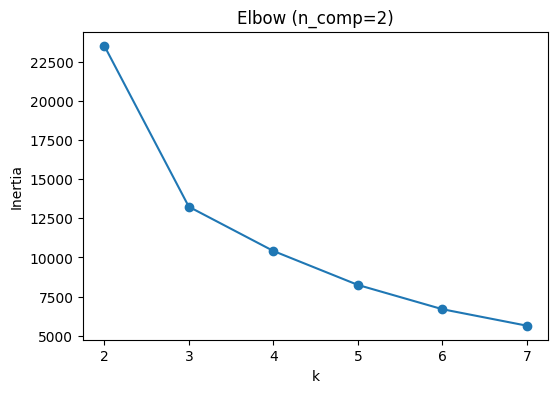

In [18]:
N_COMP = 2

sub = df_grid[df_grid["n_comp"] == N_COMP]

plt.figure(figsize=(6, 4))
plt.plot(sub["k"], sub["inertia"], marker="o")
plt.title(f"Elbow (n_comp={N_COMP})")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

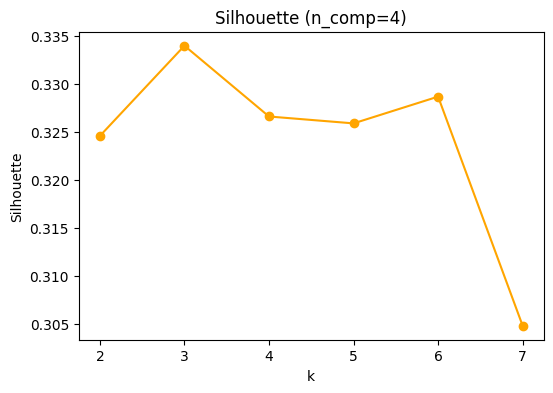

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(sub["k"], sub["silhouette"], marker="o", color="orange")
plt.title(f"Silhouette (n_comp={N_COMP})")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

In [6]:
N_COMP = 2 
K = 3

X_final = df_pca.iloc[:, :N_COMP]
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
df_clean["cluster_kmeans"] = kmeans.fit_predict(X_final)

df_clean["cluster_kmeans"].value_counts(normalize=True).round(3)

cluster_kmeans
1    0.379
2    0.350
0    0.271
Name: proportion, dtype: float64

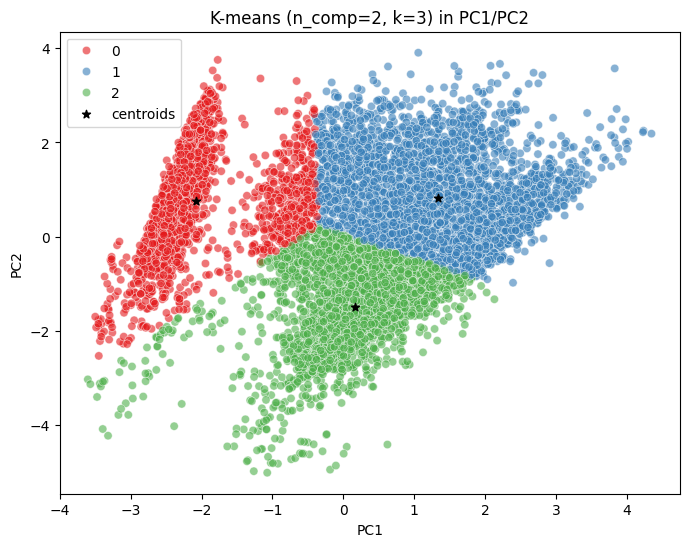

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"],
                hue=df_clean["cluster_kmeans"], palette="Set1", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="black", marker="*", label="centroids")
plt.legend()
plt.title("K-means (n_comp=2, k=3) in PC1/PC2")
plt.show()

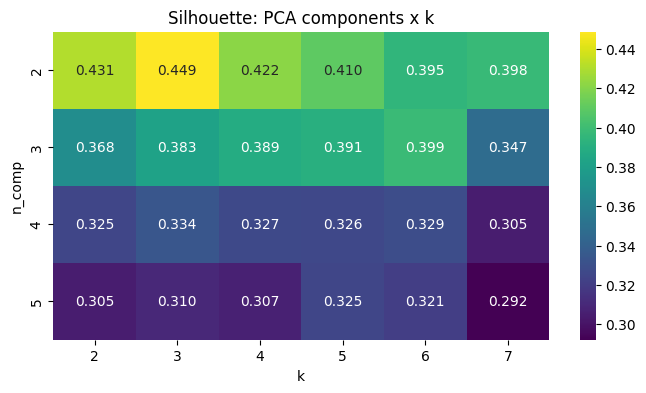

In [8]:
pivot = df_grid.pivot(index="n_comp", columns="k", values="silhouette")
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Silhouette: PCA components x k")
plt.show()

In [9]:
df_grid[df_grid["k"] == 3].sort_values("silhouette", ascending=False).round(3)

,n_comp,k,inertia,silhouette,min_cluster_pct
1,2,3,13244.220,0.449,27.132
7,3,3,20205.728,0.383,26.718
13,4,3,26443.516,0.334,26.383
19,5,3,31179.736,0.310,26.193


In [11]:
df_clean["cluster_kmeans"].value_counts(normalize=True).round(3)

cluster_kmeans
1    0.379
2    0.350
0    0.271
Name: proportion, dtype: float64

In [10]:
df_clean.to_csv('../data/processed/df_clustered.csv', index=False)